# XGBoost and LightGBM Benchmark
Cross-sectional equity return prediction in the Emerging Markets universe. Both models receive the full set of rank-normalised JKP characteristics and are evaluated against the same six-month rebalancing schedule, 25 basis-point transaction cost, and volatility overlay as the Dual Path Portfolio Transformer.

Two portfolio constructions are reported for every model: a long-short quintile portfolio for direct comparison with the dissertation headline Sharpe, and a long-only top-quintile portfolio for comparison with the MSCI EM Gross long-only benchmark. The hyperparameter search optimises validation long-short Sharpe. The long-only metrics are tracked as trial diagnostics and reported at evaluation time for the selected model.

In [1]:
import gc
import json
import time
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import pyarrow as pa
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import xgboost as xgb
import lightgbm as lgb
import optuna
from scipy.stats import spearmanr
import matplotlib
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [2]:

try:
    import torch
    cuda_available = torch.cuda.is_available()
    cuda_device_name = torch.cuda.get_device_name(0) if cuda_available else None
except ImportError:
    cuda_available = False
    cuda_device_name = None

print(f'cuda available (torch):{cuda_available}')
if cuda_available:
    print(f'cuda device:{cuda_device_name}')


def _probe(probe_fn, label):
    try:
        probe_x = np.random.randn(200, 10).astype(np.float32)
        probe_y = np.random.randn(200).astype(np.float32)
        probe_fn(probe_x, probe_y)
        return True
    except Exception as exc:
        print(f'{label}: gpu probe failed ({type(exc).__name__}: {exc})')
        return False


xgb_use_cuda = False
lgb_use_gpu = False
if cuda_available:
    xgb_use_cuda = _probe(
        lambda x, y: xgb.XGBRegressor(
            n_estimators = 5, tree_method = 'hist', device = 'cuda', verbosity = 0,
        ).fit(x, y), 'xgboost',
    )
    lgb_use_gpu = _probe(
        lambda x, y: lgb.LGBMRegressor(
            n_estimators = 5, device = 'gpu', verbose = -1,
        ).fit(x, y), 'lightgbm',
    )

xgb_device_params = {'tree_method': 'hist', 'device': 'cuda'} if xgb_use_cuda else {'tree_method': 'hist'}
lgb_device_params = {'device': 'gpu'} if lgb_use_gpu else {}


cuda available (torch):True
cuda device:NVIDIA GeForce RTX 2080 Super with Max-Q Design


In [3]:
data_path = Path('../data/Global Factor_EM.parquet')
results_dir = Path('../results/benchmark/tree_benchmark')
results_dir.mkdir(parents = True, exist_ok = True)

train_end = pd.Timestamp('2015-12-31')
val_end = pd.Timestamp('2020-12-31')

ret_col = 'ret_exc_lead1m'
rebalance_freq = 3
tc_bps = 25
min_stocks = 30
ret_clip_low = -1.0
ret_clip_high =  1.0

target_vol = 0.10
vol_lookback = 12
max_leverage_ls = 3.0
max_leverage_lo = 3.0

n_trials_xgb = 50
n_trials_lgb = 50
optuna_seed = 42
n_hpo_months = 36

In [4]:
schema = pq.read_schema(data_path)

non_feature = {
    'id', 'gvkey', 'isin', 'cusip', 'permno', 'permco',
    'eom', 'excntry', 'sic', 'naics', 'source_crsp', ret_col,
}

feature_cols = [
    c for c in schema.names
    if c not in non_feature
    and pa.types.is_floating(schema.field(c).type)
]

print(f'feature columns selected, {len(feature_cols)}')

needed = list(dict.fromkeys(
    [c for c in ['id', 'eom', 'excntry', ret_col] + feature_cols
     if c in schema.names]
))

df = pd.read_parquet(data_path, columns = needed)
df['eom'] = pd.to_datetime(df['eom'])

for col in feature_cols:
    if col in df.columns and df[col].dtype == np.float64:
        df[col] = df[col].astype(np.float32)

df[ret_col] = df[ret_col].clip(lower = ret_clip_low, upper = ret_clip_high)

print(f'loaded:{df.shape[0]:,} rows, {len(feature_cols)} characteristic columns')
print(f'date range:{df["eom"].min().date()} to {df["eom"].max().date()}')
print(f'countries{df["excntry"].nunique()}')

feature columns selected, 421
loaded:4,386,856 rows, 421 characteristic columns
date range:1995-01-31 to 2025-12-31
countries24


In [5]:
sorted_eoms = sorted(df['eom'].unique())
all_months = {}
n_feat = len(feature_cols)

for eom in sorted_eoms:
    month = df[df['eom'] == eom].copy()
    month = month[month[ret_col].notna()]
    if len(month) < min_stocks:
        continue

    ids = month['id'].values
    r   = month[ret_col].values.astype(np.float64)

    x = np.full((len(month), n_feat), np.nan, dtype = np.float32)
    for j, col in enumerate(feature_cols):
        if col not in month.columns:
            continue
        vals = month[col].astype(np.float64).to_numpy()
        valid = np.isfinite(vals)
        if valid.sum() > 1:
            ranks = pd.Series(vals[valid]).rank(pct = True).to_numpy(dtype = np.float32)
            x[valid, j] = ranks - 0.5

    all_months[eom] = {'ids': ids, 'r': r, 'x': x}

sorted_dates = sorted(all_months.keys())
print(f'processed: {len(sorted_dates)} months')
print(f'avg firms/month: {np.mean([len(m["ids"]) for m in all_months.values()]):.0f}')

processed: 372 months
avg firms/month: 11648


In [6]:
train_dates = [d for d in sorted_dates if d <= train_end]
val_dates = [d for d in sorted_dates if train_end < d <= val_end]
test_dates = [d for d in sorted_dates if d > val_end]

print(f'train:{len(train_dates)} months')
print(f'val:{len(val_dates)} months')
print(f'test:{len(test_dates)} months')

x_train = np.vstack([all_months[d]['x'] for d in train_dates])
y_train = np.concatenate([all_months[d]['r'] for d in train_dates])
print(f'x_train: {x_train.shape}')

hpo_dates = train_dates[-n_hpo_months:]
x_hpo = np.vstack([all_months[d]['x'] for d in hpo_dates])
y_hpo = np.concatenate([all_months[d]['r'] for d in hpo_dates])
print(f'x_hpo:{x_hpo.shape}')

train:252 months
val:60 months
test:60 months
x_train: (2175929, 421)
x_hpo:(514933, 421)


In [7]:
def portfolio_metrics(rets):
    rets = np.array(rets, dtype = np.float64)
    if len(rets) == 0:
        return {}
    tw = float((1.0 + rets).prod())
    ann_ret = -1.0 if tw <= 0 else float(tw ** (12.0 / len(rets)) - 1.0)
    ann_vol = float(rets.std() * np.sqrt(12.0))
    sharpe = ann_ret / max(ann_vol, 1e-8)
    se = float(np.sqrt((1.0 + 0.5 * sharpe ** 2) / len(rets)))
    cw = np.cumprod(1.0 + rets)
    pk = np.maximum.accumulate(cw)
    max_dd = float(((pk - cw) / pk).max()) if len(cw) > 0 else 0.0
    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'se_sharpe': se, 'max_dd': max_dd, 'n_obs': len(rets),
    }


def apply_vol_target(monthly_rets, rebalance_indices, target_vol, vol_lookback, max_leverage):
    scaled = np.array(monthly_rets, dtype = np.float64)
    n = len(monthly_rets)
    n_rb = len(rebalance_indices)
    period_rets = []
    for i in range(1, n_rb):
        window = np.array(monthly_rets[rebalance_indices[i - 1]:rebalance_indices[i]])
        period_rets.append(float(np.prod(1.0 + window) - 1.0))
    for i in range(n_rb):
        if i < vol_lookback:
            continue
        trailing = np.array(period_rets[max(0, i - vol_lookback):i])
        if len(trailing) < 2:
            continue
        sigma_ann = float(trailing.std() * np.sqrt(12.0 / rebalance_freq))
        lev = float(np.clip(target_vol / max(sigma_ann, 1e-8), 1.0 / max_leverage, max_leverage))
        next_rb = rebalance_indices[i + 1] if i + 1 < n_rb else n
        scaled[rebalance_indices[i]:next_rb] = (
            np.array(monthly_rets[rebalance_indices[i]:next_rb]) * lev
        )
    return scaled


def predict_test(model, month_dates):
    rows = []
    for eom in month_dates:
        if eom not in all_months:
            continue
        m = all_months[eom]
        pred = model.predict(m['x'])
        for k in range(len(m['ids'])):
            rows.append({
                'eom': eom, 'id': m['ids'][k],
                'prediction': float(pred[k]), 'realised_return': float(m['r'][k]),
            })
    return pd.DataFrame(rows)


def run_quintile_simulation(model, month_dates):
    """
    Quintile simulation producing both long-short and long-only portfolios.
    Long-short: top quintile equal-weighted long, bottom quintile equal-weighted short.
    Long-only: top quintile equal-weighted, no short leg.
    Turnover is computed per leg using firm identifiers.
    The long-only turnover counts only the long leg; the long-short turnover
    counts both legs.
    """
    rset = set(month_dates[::rebalance_freq])

    ls_rets, ls_dates, ls_rb_indices = [], [], []
    lo_rets, lo_dates, lo_rb_indices = [], [], []

    li_ids = []
    si_ids = []
    prev_li = set()
    prev_si = set()

    ls_holdings, lo_holdings = [], []
    rb_counter = -1

    for eom in month_dates:
        if eom not in all_months:
            continue
        m = all_months[eom]
        ids = m['ids']
        r = m['r']
        x = m['x']

        ls_tcv = 0.0
        lo_tcv = 0.0

        if eom in rset:
            ls_rb_indices.append(len(ls_rets))
            lo_rb_indices.append(len(lo_rets))
            rb_counter += 1

            pred = model.predict(x)
            valid = np.isfinite(pred)
            if valid.sum() < 10:
                continue

            vi = ids[valid]
            vp = pred[valid]
            nq = max(1, int(len(vi) * 0.20))
            so = np.argsort(vp)
            li_ids = vi[so[::-1][:nq]].tolist()
            si_ids = vi[so[:nq]].tolist()
            li_set = set(li_ids)
            si_set = set(si_ids)

            ls_to = (
                len(li_set - prev_li) + len(prev_li - li_set)
                + len(si_set - prev_si) + len(prev_si - si_set)
            ) / max(nq, 1)
            ls_tcv = ls_to * tc_bps / 10000.0

            lo_to = (
                len(li_set - prev_li) + len(prev_li - li_set)
            ) / max(nq, 1)
            lo_tcv = lo_to * tc_bps / 10000.0

            prev_li = li_set
            prev_si = si_set

            wt_long = 1.0 / max(len(li_ids), 1)
            wt_short = -1.0 / max(len(si_ids), 1)

            for fid in li_ids:
                ls_holdings.append({
                    'rebalance_index': rb_counter, 'eom': eom, 'leg': 'long',
                    'id': fid, 'weight': wt_long,
                })
                lo_holdings.append({
                    'rebalance_index': rb_counter, 'eom': eom, 'leg': 'long',
                    'id': fid, 'weight': wt_long,
                })
            for fid in si_ids:
                ls_holdings.append({
                    'rebalance_index': rb_counter, 'eom': eom, 'leg': 'short',
                    'id': fid, 'weight': wt_short,
                })

        if not li_ids:
            continue

        li_mask = np.isin(ids, li_ids)
        si_mask = np.isin(ids, si_ids)
        lr = r[li_mask]
        sr = r[si_mask]
        lr_mean = float(lr.mean()) if len(lr) > 0 else 0.0
        sr_mean = float(sr.mean()) if len(sr) > 0 else 0.0

        ls_rets.append(lr_mean - sr_mean - ls_tcv)
        ls_dates.append(eom)

        lo_rets.append(lr_mean - lo_tcv)
        lo_dates.append(eom)

    return {
        'long_short': {
            'returns': np.array(ls_rets),
            'rb_indices': ls_rb_indices,
            'holdings_df': pd.DataFrame(ls_holdings),
            'returns_df': pd.DataFrame({'eom': ls_dates, 'return_raw': ls_rets}),
        },
        'long_only': {
            'returns': np.array(lo_rets),
            'rb_indices': lo_rb_indices,
            'holdings_df': pd.DataFrame(lo_holdings),
            'returns_df': pd.DataFrame({'eom': lo_dates, 'return_raw': lo_rets}),
        },
    }

### Hyperparameter search

In [8]:
# xgboost hyperparameter tuning, skip if results are already saved

xgb_best_params_path = results_dir / 'xgb_best_params.json'
xgb_study_path = results_dir / 'xgb_optuna_study.pkl'
xgb_trials_path = results_dir / 'xgb_optuna_trials.csv'

if xgb_best_params_path.exists():
    with open(xgb_best_params_path) as fh:
        cached = json.load(fh)
    xgb_best = cached['best_params']
    xgb_best_value = cached['best_value']
    xgb_hpo_time = cached['hpo_time_seconds']

    if xgb_study_path.exists():
        with open(xgb_study_path, 'rb') as fh:
            xgb_study = pickle.load(fh)
    else:
        xgb_study = None

    print(f'XGBoost hyperparameters already tuned, loaded from {xgb_best_params_path.name}')
    print(f'XGBoost best val ls sharpe, {xgb_best_value:.4f}')
    print(f'XGBoost best params, {xgb_best}')
else:
    def xgb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log = True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 5.0, log = True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 5.0, log = True),
            'random_state': optuna_seed,
            'n_jobs': -1,
            'verbosity': 0,
            **xgb_device_params,
        }
        model = xgb.XGBRegressor(**params)
        model.fit(x_hpo, y_hpo)

        sim = run_quintile_simulation(model, val_dates)
        ls = sim['long_short']
        lo = sim['long_only']

        if len(ls['returns']) == 0:
            return -999.0

        ls_scaled = apply_vol_target(ls['returns'], ls['rb_indices'], target_vol, vol_lookback, max_leverage_ls)
        lo_scaled = apply_vol_target(lo['returns'], lo['rb_indices'], target_vol, vol_lookback, max_leverage_lo)

        ls_sharpe = portfolio_metrics(ls_scaled).get('sharpe', -999.0)
        lo_sharpe = portfolio_metrics(lo_scaled).get('sharpe', -999.0)

        trial.set_user_attr('val_sharpe_long_only', float(lo_sharpe))
        return ls_sharpe


    xgb_study = optuna.create_study(
        direction = 'maximize',
        sampler = optuna.samplers.TPESampler(seed = optuna_seed),
    )
    t0 = time.time()
    xgb_study.optimize(xgb_objective, n_trials = n_trials_xgb, show_progress_bar = True)
    xgb_hpo_time = time.time() - t0
    xgb_best = xgb_study.best_params
    xgb_best_value = float(xgb_study.best_value)

    with open(xgb_best_params_path, 'w') as fh:
        json.dump({
            'best_params': xgb_best,
            'best_value': xgb_best_value,
            'best_trial_number': int(xgb_study.best_trial.number),
            'best_trial_user_attrs': dict(xgb_study.best_trial.user_attrs),
            'n_trials_completed': sum(1 for t in xgb_study.trials if t.state.name == 'COMPLETE'),
            'hpo_time_seconds': float(xgb_hpo_time),
        }, fh, indent = 2, default = float)

    xgb_trials_df = xgb_study.trials_dataframe()
    xgb_trials_df.to_csv(xgb_trials_path, index = False)
    with open(xgb_study_path, 'wb') as fh:
        pickle.dump(xgb_study, fh)

    print(f'XGBoost best val ls sharpe, {xgb_best_value:.4f}')
    print(f'XGBoost best params, {xgb_best}')
    print(f'XGBoost hpo time, {xgb_hpo_time:.1f} s, {xgb_hpo_time / 60:.2f} min')
    print(f'xgboost trials saved, {len(xgb_trials_df)} rows')


# lightgbm hyperparameter tuning, skip if results are already saved

lgb_best_params_path = results_dir / 'em_lgb_best_params.json'
lgb_study_path = results_dir / 'em_lgb_optuna_study.pkl'
lgb_trials_path = results_dir / 'em_lgb_optuna_trials.csv'

if lgb_best_params_path.exists():
    with open(lgb_best_params_path) as fh:
        cached = json.load(fh)
    lgb_best = cached['best_params']
    lgb_best_value = cached['best_value']
    lgb_hpo_time = cached['hpo_time_seconds']

    if lgb_study_path.exists():
        with open(lgb_study_path, 'rb') as fh:
            lgb_study = pickle.load(fh)
    else:
        lgb_study = None

    print(f'LightGBM hyperparameters already tuned, loaded from {lgb_best_params_path.name}')
    print(f'LightGBM best val ls sharpe, {lgb_best_value:.4f}')
    print(f'LightGBM best params, {lgb_best}')
else:
    def lgb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log = True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 5.0, log = True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 5.0, log = True),
            'random_state': optuna_seed,
            'n_jobs': -1,
            'verbose': -1,
            **lgb_device_params,
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(x_hpo, y_hpo)

        sim = run_quintile_simulation(model, val_dates)
        ls = sim['long_short']
        lo = sim['long_only']

        if len(ls['returns']) == 0:
            return -999.0

        ls_scaled = apply_vol_target(ls['returns'], ls['rb_indices'], target_vol, vol_lookback, max_leverage_ls)
        lo_scaled = apply_vol_target(lo['returns'], lo['rb_indices'], target_vol, vol_lookback, max_leverage_lo)

        ls_sharpe = portfolio_metrics(ls_scaled).get('sharpe', -999.0)
        lo_sharpe = portfolio_metrics(lo_scaled).get('sharpe', -999.0)

        trial.set_user_attr('val_sharpe_long_only', float(lo_sharpe))
        return ls_sharpe


    lgb_study = optuna.create_study(
        direction = 'maximize',
        sampler = optuna.samplers.TPESampler(seed = optuna_seed),
    )
    t0 = time.time()
    lgb_study.optimize(lgb_objective, n_trials = n_trials_lgb, show_progress_bar = True)
    lgb_hpo_time = time.time() - t0
    lgb_best = lgb_study.best_params
    lgb_best_value = float(lgb_study.best_value)

    with open(lgb_best_params_path, 'w') as fh:
        json.dump({
            'best_params': lgb_best,
            'best_value': lgb_best_value,
            'best_trial_number': int(lgb_study.best_trial.number),
            'best_trial_user_attrs': dict(lgb_study.best_trial.user_attrs),
            'n_trials_completed': sum(1 for t in lgb_study.trials if t.state.name == 'COMPLETE'),
            'hpo_time_seconds': float(lgb_hpo_time),
        }, fh, indent = 2, default = float)

    lgb_trials_df = lgb_study.trials_dataframe()
    lgb_trials_df.to_csv(lgb_trials_path, index = False)
    with open(lgb_study_path, 'wb') as fh:
        pickle.dump(lgb_study, fh)

    print(f'LightGBM best val ls sharpe, {lgb_best_value:.4f}')
    print(f'LightGBM best params, {lgb_best}')
    print(f'LightGBM hpo time, {lgb_hpo_time:.1f} s, {lgb_hpo_time / 60:.2f} min')
    print(f'lightgbm trials saved, {len(lgb_trials_df)} rows')

  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost best val ls sharpe, 2.0856
XGBoost best params, {'n_estimators': 393, 'max_depth': 5, 'learning_rate': 0.08481054350447192, 'subsample': 0.936954488824697, 'colsample_bytree': 0.5999765571598739, 'min_child_weight': 14, 'reg_alpha': 0.024713521040881543, 'reg_lambda': 1.3723145380488813}
XGBoost hpo time, 1463.3 s, 24.39 min
xgboost trials saved, 50 rows


  0%|          | 0/50 [00:00<?, ?it/s]

LightGBM best val ls sharpe, 2.2413
LightGBM best params, {'n_estimators': 482, 'max_depth': 6, 'learning_rate': 0.10446579572431045, 'num_leaves': 61, 'subsample': 0.7640881690357239, 'colsample_bytree': 0.5264174990326803, 'min_child_samples': 11, 'reg_alpha': 0.013465980973646114, 'reg_lambda': 1.905435175842351}
LightGBM hpo time, 1617.9 s, 26.97 min
lightgbm trials saved, 50 rows


In [9]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


class XGBPredictor:
    """Thin wrapper exposing sklearn style predict, save_model, and feature_importances_."""
    def __init__(self, booster):
        self.booster = booster

    def predict(self, x):
        if not isinstance(x, xgb.DMatrix):
            x = xgb.DMatrix(x)
        return self.booster.predict(x)

    def save_model(self, path):
        self.booster.save_model(path)

    @property
    def feature_importances_(self):
        score = self.booster.get_score(importance_type = 'gain')
        imp = np.zeros(len(feature_cols), dtype = np.float64)
        for k, v in score.items():
            try:
                idx = int(k.lstrip('f'))
                if 0 <= idx < len(imp):
                    imp[idx] = v
            except ValueError:
                continue
        return imp


class ChunkIter(xgb.DataIter):
    """
    Hand the training matrix to xgboost in chunks. xgboost stores the
    quantised form of each chunk on disk and discards the raw chunk after
    consumption, so the peak memory footprint is bounded by the chunk size
    rather than by the full matrix.
    """
    def __init__(self, x, y, chunk_size, cache_prefix):
        self.x = x
        self.y = y
        self.chunk_size = chunk_size
        self.n_chunks = (len(x) + chunk_size - 1) // chunk_size
        self.current = 0
        super().__init__(cache_prefix = cache_prefix)

    def next(self, input_data):
        if self.current >= self.n_chunks:
            return 0
        start = self.current * self.chunk_size
        end = min(start + self.chunk_size, len(self.x))
        input_data(data = self.x[start:end], label = self.y[start:end])
        self.current += 1
        return 1

    def reset(self):
        self.current = 0


# build the booster parameter dictionary with explicit precedence
xgb_final_params = {**xgb_device_params, **xgb_best}
xgb_final_params['tree_method'] = 'hist'
xgb_final_params['max_bin'] = 64
xgb_final_params['device'] = 'cpu'
xgb_final_params['objective'] = 'reg:squarederror'
xgb_final_params['seed'] = optuna_seed
xgb_final_params['nthread'] = -1

n_estimators = int(xgb_final_params.pop('n_estimators', 100))

# cache directory for the external memory mode
cache_dir = results_dir / 'xgb_cache'
cache_dir.mkdir(parents = True, exist_ok = True)

# build the external memory quantile dmatrix through the iterator
print('building xgboost external memory training matrix')
it = ChunkIter(
    x = x_train,
    y = y_train,
    chunk_size = 200000,
    cache_prefix = str(cache_dir / 'iter'),
)
dtrain = xgb.ExtMemQuantileDMatrix(it, max_bin = 64)
print(f'matrix built, {dtrain.num_row():,} rows, {dtrain.num_col()} columns')

del it
gc.collect()

t0 = time.time()
xgb_booster = xgb.train(
    params = xgb_final_params,
    dtrain = dtrain,
    num_boost_round = n_estimators,
    verbose_eval = False,
)
xgb_train_time = time.time() - t0
xgb_model = XGBPredictor(xgb_booster)

del dtrain
gc.collect()
print(f'XGBoost final model trained in {xgb_train_time:.1f} s')


# release memory before lightgbm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# lightgbm uses its own dataset construction and does not suffer from the
# same single allocation problem
lgb_final_params = {**lgb_device_params, **lgb_best}
lgb_final_params['max_bin'] = 128

lgb_model = lgb.LGBMRegressor(
    **lgb_final_params,
    random_state = optuna_seed,
    n_jobs = -1,
    verbose = -1,
)
t0 = time.time()
lgb_model.fit(x_train, y_train)
lgb_train_time = time.time() - t0
print(f'LightGBM final model trained in {lgb_train_time:.1f} s')


gc.collect()


xgb_model.save_model(str(results_dir / 'em_xgb_model.json'))
lgb_model.booster_.save_model(str(results_dir / 'em_lgb_model.txt'))
print('models saved in native formats')

building xgboost external memory training matrix
matrix built, 2,175,929 rows, 421 columns
XGBoost final model trained in 1432.3 s
LightGBM final model trained in 74.0 s
models saved in native formats


In [10]:
def rank_correlation_oos(model, month_dates):
    corrs = []
    for eom in month_dates:
        if eom not in all_months:
            continue
        m = all_months[eom]
        pred = model.predict(m['x'])
        valid = np.isfinite(pred) & np.isfinite(m['r'])
        if valid.sum() < 10:
            continue
        c, _ = spearmanr(pred[valid], m['r'][valid])
        if not np.isnan(c):
            corrs.append(float(c))
    return float(np.mean(corrs)) if corrs else 0.0


xgb_rc_val = rank_correlation_oos(xgb_model, val_dates)
xgb_rc_test = rank_correlation_oos(xgb_model, test_dates)
lgb_rc_val = rank_correlation_oos(lgb_model, val_dates)
lgb_rc_test = rank_correlation_oos(lgb_model, test_dates)

print(f'XGBoost rank corr: val = {xgb_rc_val:.4f}, test = {xgb_rc_test:.4f}')
print(f'LightGBM rank corr: val = {lgb_rc_val:.4f}, test = {lgb_rc_test:.4f}')

XGBoost rank corr: val = 0.0477, test = 0.0690
LightGBM rank corr: val = 0.0477, test = 0.0365


In [11]:
# test set simulation: both long-short and long-only for each model

def evaluate_and_save(model, name):
    sim = run_quintile_simulation(model, test_dates)
    ls = sim['long_short']
    lo = sim['long_only']

    ls_scaled = apply_vol_target(ls['returns'], ls['rb_indices'], target_vol, vol_lookback, max_leverage_ls)
    lo_scaled = apply_vol_target(lo['returns'], lo['rb_indices'], target_vol, vol_lookback, max_leverage_lo)

    ls['returns_df']['return_scaled'] = ls_scaled
    lo['returns_df']['return_scaled'] = lo_scaled

    m_ls_raw = portfolio_metrics(ls['returns'])
    m_ls_scaled = portfolio_metrics(ls_scaled)
    m_lo_raw = portfolio_metrics(lo['returns'])
    m_lo_scaled = portfolio_metrics(lo_scaled)

    ls['returns_df'].to_csv(results_dir / f'em_{name}_returns_long_short.csv', index = False)
    lo['returns_df'].to_csv(results_dir / f'em_{name}_returns_long_only.csv', index = False)
    ls['holdings_df'].to_csv(results_dir / f'em_{name}_holdings_long_short.csv', index = False)
    lo['holdings_df'].to_csv(results_dir / f'em_{name}_holdings_long_only.csv', index = False)

    predict_test(model, test_dates).to_csv(
        results_dir / f'em_{name}_test_predictions.csv', index = False,
    )

    return {
        'returns_ls_raw': ls['returns'],
        'returns_ls_scaled': ls_scaled,
        'returns_lo_raw': lo['returns'],
        'returns_lo_scaled': lo_scaled,
        'metrics':{
            'long_short_raw': m_ls_raw,
            'long_short_scaled': m_ls_scaled,
            'long_only_raw': m_lo_raw,
            'long_only_scaled':  m_lo_scaled,
        },
    }


xgb_eval = evaluate_and_save(xgb_model, 'xgb')
lgb_eval = evaluate_and_save(lgb_model, 'lgb')

for name, ev in [('XGBoost', xgb_eval), ('LightGBM', lgb_eval)]:
    mls = ev['metrics']['long_short_scaled']
    mlo = ev['metrics']['long_only_scaled']
    print(f'{name} long-short (vol):sharpe = {mls["sharpe"]:.4f}, ann_ret = {mls["ann_ret"] * 100:.2f}%, ann_vol = {mls["ann_vol"] * 100:.2f}%')
    print(f'{name} long-only (vol):sharpe = {mlo["sharpe"]:.4f}, ann_ret = {mlo["ann_ret"] * 100:.2f}%, ann_vol = {mlo["ann_vol"] * 100:.2f}%')

XGBoost long-short (vol):sharpe = 2.8322, ann_ret = 28.65%, ann_vol = 10.12%
XGBoost long-only (vol):sharpe = 2.6947, ann_ret = 27.19%, ann_vol = 10.09%
LightGBM long-short (vol):sharpe = 2.2501, ann_ret = 22.45%, ann_vol = 9.98%
LightGBM long-only (vol):sharpe = 1.9686, ann_ret = 21.81%, ann_vol = 11.08%


In [12]:
xgb_imp = pd.DataFrame({
    'feature': feature_cols, 'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending = False)
lgb_imp = pd.DataFrame({
    'feature': feature_cols, 'importance': lgb_model.feature_importances_,
}).sort_values('importance', ascending = False)

xgb_imp.to_csv(results_dir / 'em_xgb_feature_importance.csv', index = False)
lgb_imp.to_csv(results_dir / 'em_lgb_feature_importance.csv', index = False)

print('top 10 xgboost features')
print(xgb_imp.head(10).to_string(index = False))
print('top 10 lightgbm features')
print(lgb_imp.head(10).to_string(index = False))

top 10 xgboost features
         feature  importance
          ocf_me   18.878836
     primary_sec   13.538481
       chcsho_1m   12.512176
        obs_main   12.271656
         eqbb_me   11.980888
     ret_lag_dif   11.900226
             age   11.556497
prc_highprc_252d   11.160742
     roeq_be_std   11.097108
       chcsho_3m   10.907966
top 10 lightgbm features
    feature  importance
         fx        1675
ret_lag_dif        1375
  chcsho_1m         994
   eqnpo_1m         894
        age         636
  exch_main         566
     common         545
   obs_main         538
     bidask         490
  chcsho_3m         476


In [13]:
summary = {
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'split': {
        'train': {'start': str(train_dates[0].date()), 'end': str(train_dates[-1].date()),
                  'n_months': len(train_dates), 'n_obs': int(x_train.shape[0])},
        'val': {'start': str(val_dates[0].date()), 'end': str(val_dates[-1].date()),
                'n_months': len(val_dates)},
        'test': {'start': str(test_dates[0].date()), 'end': str(test_dates[-1].date()),
                 'n_months': len(test_dates)},
        'hpo': {'start': str(hpo_dates[0].date()), 'end': str(hpo_dates[-1].date()),
                'n_months': len(hpo_dates), 'n_obs': int(x_hpo.shape[0])},
    },
    'config': {
        'rebalance_freq': rebalance_freq, 'tc_bps': tc_bps, 'min_stocks': min_stocks,
        'ret_clip': [ret_clip_low, ret_clip_high],
        'target_vol': target_vol, 'vol_lookback': vol_lookback,
        'max_leverage_ls': max_leverage_ls, 'max_leverage_lo': max_leverage_lo,
        'optuna_seed': optuna_seed,
        'n_trials_xgb': n_trials_xgb, 'n_trials_lgb': n_trials_lgb,
    },
    'xgboost': {
        'best_params': xgb_best,
        'best_val_long_short_sharpe': float(xgb_study.best_value) if xgb_study is not None else float(xgb_best_value),
        'rc_val': float(xgb_rc_val), 'rc_test': float(xgb_rc_test),
        'final_training_time_seconds': float(xgb_train_time),
        'portfolio_metrics': xgb_eval['metrics'],
    },
    'lightgbm': {
        'best_params': lgb_best,
        'best_val_long_short_sharpe': float(lgb_study.best_value) if lgb_study is not None else float(lgb_best_value),
        'rc_val': float(lgb_rc_val), 'rc_test': float(lgb_rc_test),
        'final_training_time_seconds': float(lgb_train_time),
        'portfolio_metrics': lgb_eval['metrics'],
    },
}

with open(results_dir / 'em_tree_summary.json', 'w') as fh:
    json.dump(summary, fh, indent = 2, default = float)
print(f'summary saved to {results_dir / "em_tree_summary.json"}')

# tabular results via DataFrame for clean alignment, both raw and scaled
rows = []
for name, ev, rc in [('xgboost', xgb_eval, xgb_rc_test), ('lightgbm', lgb_eval, lgb_rc_test)]:
    for portfolio, scaling, key in [
        ('long_short', 'unscaled', 'long_short_raw'),
        ('long_short', 'scaled', 'long_short_scaled'),
        ('long_only', 'unscaled', 'long_only_raw'),
        ('long_only', 'scaled', 'long_only_scaled'),
    ]:
        m = ev['metrics'][key]
        rows.append({
            'model': name,
            'portfolio': portfolio,
            'scaling': scaling,
            'rc_test': round(rc, 4),
            'sharpe': round(m['sharpe'], 4),
            'se': round(m['se_sharpe'], 4),
            'ann_ret': round(m['ann_ret'] * 100, 2),
            'ann_vol': round(m['ann_vol'] * 100, 2),
            'max_dd': round(m['max_dd'] * 100, 2),
            'n_obs': m['n_obs'],
        })
summary_table = pd.DataFrame(rows)
print('\nTree Benchmark, EM Universe, test set, Unscaled and vol-targeted')
print(summary_table.to_string(index = False))
summary_table.to_csv(results_dir / 'em_tree_summary.csv', index = False)
print('summary csv saved')


summary saved to ..\results\benchmark\tree_benchmark\em_tree_summary.json

Tree Benchmark, EM Universe, test set, Unscaled and vol-targeted
   model  portfolio  scaling  rc_test  sharpe     se  ann_ret  ann_vol  max_dd  n_obs
 xgboost long_short unscaled   0.0690  3.1500 0.3152    28.10     8.92   10.33     60
 xgboost long_short   scaled   0.0690  2.8322 0.2890    28.65    10.12   14.34     60
 xgboost  long_only unscaled   0.0690  2.7334 0.2809    27.61    10.10    5.35     60
 xgboost  long_only   scaled   0.0690  2.6947 0.2778    27.19    10.09    5.35     60
lightgbm long_short unscaled   0.0365  2.3262 0.2485    21.98     9.45    3.81     60
lightgbm long_short   scaled   0.0365  2.2501 0.2426    22.45     9.98    4.72     60
lightgbm  long_only unscaled   0.0365  2.0237 0.2254    23.31    11.52   11.32     60
lightgbm  long_only   scaled   0.0365  1.9686 0.2213    21.81    11.08   11.32     60
summary csv saved


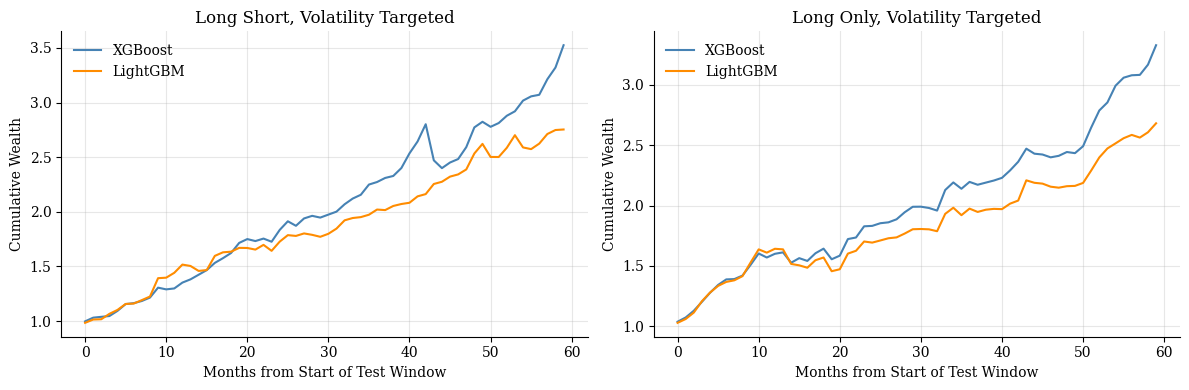

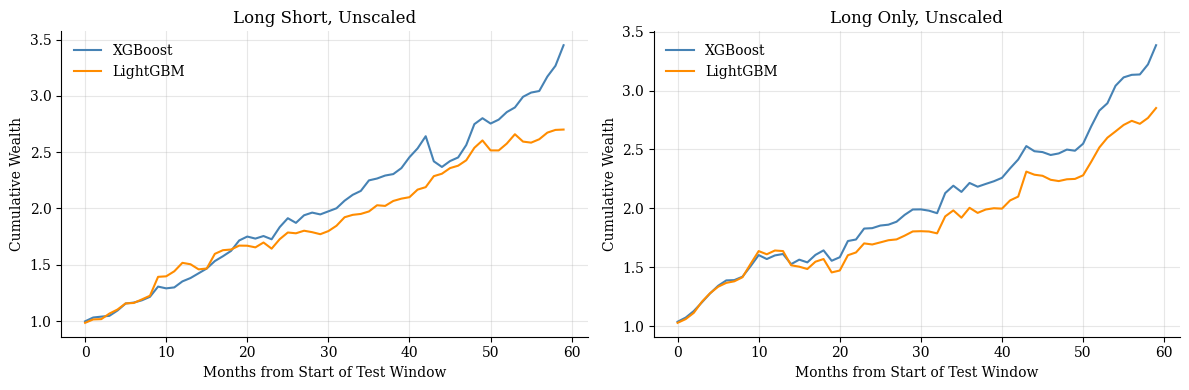

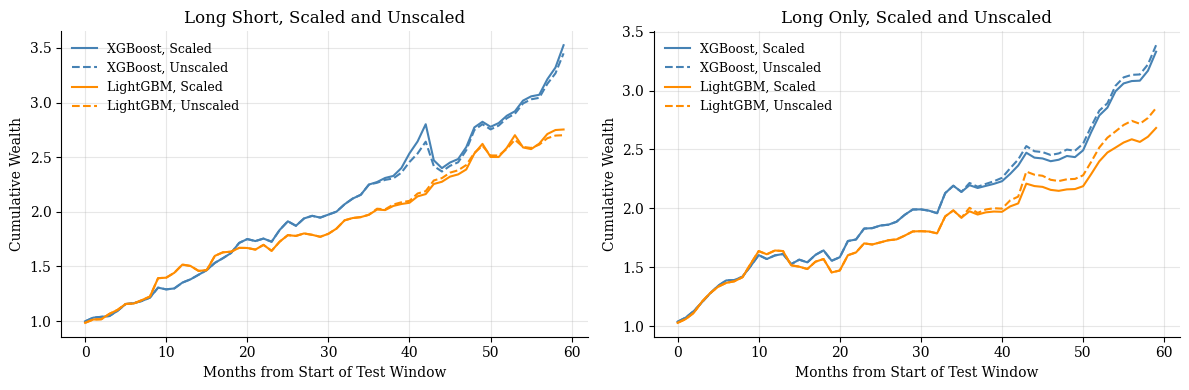

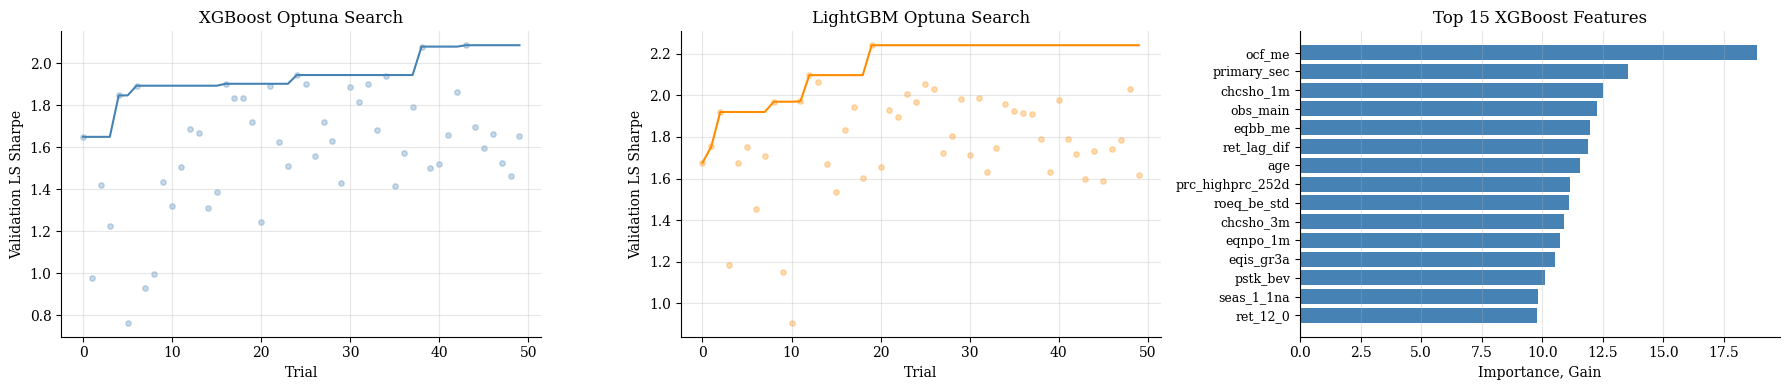

plots saved, em_tree_cumulative_scaled, em_tree_cumulative_unscaled, em_tree_cumulative_combined, em_tree_diagnostics


In [14]:
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
})

xgb_color = 'steelblue'
lgb_color = 'darkorange'


# figure 1, volatility targeted cumulative wealth
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_scaled']), label = 'XGBoost', color = xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_scaled']), label = 'LightGBM', color = lgb_color)
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Volatility Targeted')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_scaled']), label = 'XGBoost', color = xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_scaled']), label = 'LightGBM', color = lgb_color)
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Volatility Targeted')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(results_dir / 'em_tree_cumulative_scaled.pdf')
fig.savefig(results_dir / 'em_tree_cumulative_scaled.png')
plt.show()
plt.close(fig)


# figure 2, unscaled cumulative wealth
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_raw']), label = 'XGBoost', color = xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_raw']), label = 'LightGBM', color = lgb_color)
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Unscaled')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_raw']), label = 'XGBoost', color = xgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_raw']), label = 'LightGBM', color = lgb_color)
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Unscaled')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(results_dir / 'em_tree_cumulative_unscaled.pdf')
fig.savefig(results_dir / 'em_tree_cumulative_unscaled.png')
plt.show()
plt.close(fig)


# figure 3, scaled and unscaled overlaid, solid is scaled, dashed is unscaled,
# each model retains its colour across the two line styles
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_scaled']), label = 'XGBoost, Scaled', color = xgb_color)
ax.plot(np.cumprod(1 + xgb_eval['returns_ls_raw']), label = 'XGBoost, Unscaled', color = xgb_color, linestyle = '--')
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_scaled']), label = 'LightGBM, Scaled', color = lgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_ls_raw']), label = 'LightGBM, Unscaled', color = lgb_color, linestyle = '--')
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Scaled and Unscaled')
ax.legend(frameon = False, fontsize = 9, loc = 'upper left')
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_scaled']), label = 'XGBoost, Scaled', color = xgb_color)
ax.plot(np.cumprod(1 + xgb_eval['returns_lo_raw']), label = 'XGBoost, Unscaled', color = xgb_color, linestyle = '--')
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_scaled']), label = 'LightGBM, Scaled', color = lgb_color)
ax.plot(np.cumprod(1 + lgb_eval['returns_lo_raw']), label = 'LightGBM, Unscaled', color = lgb_color, linestyle = '--')
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Scaled and Unscaled')
ax.legend(frameon = False, fontsize = 9, loc = 'upper left')
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(results_dir / 'em_tree_cumulative_combined.pdf')
fig.savefig(results_dir / 'em_tree_cumulative_combined.png')
plt.show()
plt.close(fig)


# figure 4, tree specific diagnostics preserving the optuna search progress
# and the xgboost feature importance ranking
fig, axes = plt.subplots(1, 3, figsize = (18, 4))

if xgb_study is not None:
    xgb_vals = [t.value for t in xgb_study.trials if t.value is not None]
    axes[0].plot(np.maximum.accumulate(xgb_vals), color = xgb_color)
    axes[0].scatter(range(len(xgb_vals)), xgb_vals, alpha = 0.3, s = 15, color = xgb_color)
    axes[0].set_xlabel('Trial')
    axes[0].set_ylabel('Validation LS Sharpe')
    axes[0].set_title('XGBoost Optuna Search')
    axes[0].grid(alpha = 0.3)
else:
    axes[0].text(0.5, 0.5, 'XGBoost study not in memory', ha = 'center', va = 'center')
    axes[0].set_title('XGBoost Optuna Search')

if lgb_study is not None:
    lgb_vals = [t.value for t in lgb_study.trials if t.value is not None]
    axes[1].plot(np.maximum.accumulate(lgb_vals), color = lgb_color)
    axes[1].scatter(range(len(lgb_vals)), lgb_vals, alpha = 0.3, s = 15, color = lgb_color)
    axes[1].set_xlabel('Trial')
    axes[1].set_ylabel('Validation LS Sharpe')
    axes[1].set_title('LightGBM Optuna Search')
    axes[1].grid(alpha = 0.3)
else:
    axes[1].text(0.5, 0.5, 'LightGBM study not in memory', ha = 'center', va = 'center')
    axes[1].set_title('LightGBM Optuna Search')

top_xgb_imp = xgb_imp.head(15)
axes[2].barh(range(len(top_xgb_imp)), top_xgb_imp['importance'][::-1], color = xgb_color)
axes[2].set_yticks(range(len(top_xgb_imp)))
axes[2].set_yticklabels(top_xgb_imp['feature'][::-1], fontsize = 9)
axes[2].set_xlabel('Importance, Gain')
axes[2].set_title('Top 15 XGBoost Features')
axes[2].grid(axis = 'x', alpha = 0.3)

fig.tight_layout()
fig.savefig(results_dir / 'em_tree_diagnostics.pdf')
fig.savefig(results_dir / 'em_tree_diagnostics.png')
plt.show()
plt.close(fig)

print('plots saved, em_tree_cumulative_scaled, em_tree_cumulative_unscaled, em_tree_cumulative_combined, em_tree_diagnostics')
